# 📌 ENSEMBLE LEARNING HOMEWORK

## 📔 Giới thiệu
- Tải và thực hiện khám phá bộ dữ liệu [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic).
- Huấn luyện mô hình học máy/học sâu kết hợp với kỹ thuật Ensemble Learning (Bagging/Boosting/Stacking) và báo cáo lại benchmark (có so sánh các mô hình/kĩ thuật với nhau).
- Dự đoán trên tập test của cuộc thi Kaggle và báo cáo lại `score`.

## 👀 Yêu cầu:
- Viết toàn bộ mã nguồn vào một file `.ipynb`.
- Trong notebook, cùng với các cell code phải có các cell văn bản để giải thích dữ liệu/kĩ thuật.
- Kết quả trên leaderboard của cuộc thì phải trên `80%`.

## 1. Cài đặt và Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

## 2. Tải và Khám phá dữ liệu (EDA)
Đọc dữ liệu `train.csv` và `test.csv`.

In [2]:
# Thay đổi đường dẫn này nếu bạn chạy ở local. Nếu trên Kaggle, path thường là '/kaggle/input/spaceship-titanic/...'
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Kích thước tập train: {train_df.shape}")
print(f"Kích thước tập test: {test_df.shape}")

train_df.head()

Kích thước tập train: (8693, 14)
Kích thước tập test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### EDA
Phân tích tỷ lệ nhãn mục tiêu (Transported) và các đặc trưng quan trọng.

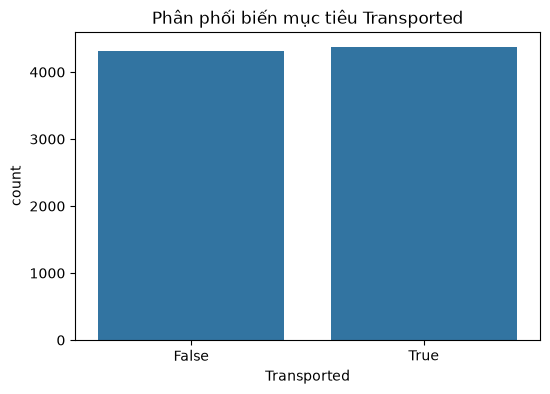

Missing values trong tập Train
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='Transported')
plt.title('Phân phối biến mục tiêu Transported')
plt.show()

# Kiểm tra dữ liệu thiếu
print("Missing values trong tập Train")
print(train_df.isnull().sum())

## 3. Preprocessing & Feature Engineering
Trong phần này, ta sẽ làm sạch dữ liệu và tạo ra các đặc trưng mới giúp mô hình học tốt hơn, cụ thể là:
1. Xử lý Missing Values: Điền giá trị median cho biến liên tục như 'Age', và điền giá trị xuất hiện nhiều nhất (mode) cho các biến phân loại.
2. Khai thác cột Cabin: Tách cột 'Cabin' thành 2 thông tin quan trọng là 'Deck' và 'Side' vì vị trí phòng có thể ảnh hưởng đến tỷ lệ bị dịch chuyển.
3. Tính tổng chi tiêu: Gom tất cả các cột chi phí trên tàu thành một cột 'TotalSpend'.
4. Suy luận logic: Dựa vào thực tế là những người đang ngủ đông ('CryoSleep' = True) thì không thể mua sắm. Do đó, nếu ai bị thiếu dữ liệu ngủ đông nhưng có tiêu tiền, ta suy ra họ đang không ngủ đông, và ngược lại.

In [11]:
def preprocessing(df):
    df_clean = df.copy()
    
    # 1. Điền dữ liệu thiếu
    df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
    df_clean['VIP'] = df_clean['VIP'].fillna(False)
    df_clean['HomePlanet'] = df_clean['HomePlanet'].fillna(df_clean['HomePlanet'].mode()[0])
    df_clean['Destination'] = df_clean['Destination'].fillna(df_clean['Destination'].mode()[0])

    # 2. Xử lý cột Cabin (Vị trí phòng)
    df_clean['Cabin'] = df_clean['Cabin'].fillna('Z/9999/Z')
    df_clean['Deck'] = df_clean['Cabin'].str.split('/').str[0]
    df_clean['Side'] = df_clean['Cabin'].str.split('/').str[2]
    
    # 3. Tính tổng chi tiêu
    cac_cot_tien = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for cot in cac_cot_tien:
        df_clean[cot] = df_clean[cot].fillna(0)
    df_clean['TotalSpend'] = df_clean['RoomService'] + df_clean['FoodCourt'] + df_clean['ShoppingMall'] + df_clean['Spa'] + df_clean['VRDeck']
    
    # 4. Suy luận người ngủ đông (CryoSleep)
    co_tieu_tien = df_clean['TotalSpend'] > 0
    khong_tieu_tien = df_clean['TotalSpend'] == 0
    thieu_du_lieu_ngu_dong = df_clean['CryoSleep'].isnull()
    
    df_clean.loc[thieu_du_lieu_ngu_dong & co_tieu_tien, 'CryoSleep'] = False
    df_clean.loc[thieu_du_lieu_ngu_dong & khong_tieu_tien, 'CryoSleep'] = True
    
    # Xóa cột không cần thiết
    cot_can_xoa = ['PassengerId', 'Name', 'Cabin']
    df_clean = df_clean.drop(columns=cot_can_xoa)
    
    return df_clean

# Áp dụng lên dữ liệu Train và Test
train_processed = preprocessing(train_df)
test_processed = preprocessing(test_df)

# Tách biến mục tiêu (Label)
y = train_processed['Transported'].astype(int)
X = train_processed.drop('Transported', axis=1)

### Label Encoding
Các mô hình học máy (đặc biệt là XGBoost, Random Forest) không thể đọc hiểu trực tiếp dạng chữ (Text/String). Do đó, ta cần sử dụng kĩ thuật Label Encoding để chuyển các danh mục bằng chữ (ví dụ: Trái đất, Sao Hỏa) thành các con số (0, 1, 2...). 

In [13]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['HomePlanet', 'Destination', 'CryoSleep', 'VIP', 'Deck', 'Side']

for col in label_cols:
    le = LabelEncoder()
    # Gom chữ cả train và test để fit (dạy cho bộ chuyển đổi)
    tat_ca_chu = list(X[col].astype(str)) + list(test_processed[col].astype(str))
    le.fit(tat_ca_chu)
    
    # Thực hiện chuyển chữ thành số
    X[col] = le.transform(X[col].astype(str))
    test_processed[col] = le.transform(test_processed[col].astype(str))

## 4. Mô hình hóa với Ensemble Learning
Chúng ta sẽ áp dụng các kỹ thuật sau:
- **Bagging**: Random Forest (Kết hợp nhiều cây quyết định độc lập).
- **Boosting**: XGBoost, LightGBM, CatBoost (Xây dựng cây tuần tự, cây sau sửa lỗi cây trước - rất mạnh với tabular data).

Chúng ta sẽ benchmark các mô hình này qua 5-Fold Cross Validation.

In [14]:
# Khởi tạo các mô hình
random_state = 42

rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=random_state)
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=random_state, eval_metric='logloss')
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=random_state)
catb = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, random_state=random_state, verbose=0)

models = {
    'Random Forest (Bagging)': rf,
    'XGBoost (Boosting)': xgb,
    'LightGBM (Boosting)': lgbm,
    'CatBoost (Boosting)': catb
}

### Đánh giá các mô hình bằng Cross-Validation

Để biết chính xác model nào dự đoán giỏi nhất, ta không cho họ xem toàn bộ đáp án cùng lúc, ta áp dụng kĩ thuật 5-Fold Cross Validation:
- Chia dữ liệu ra làm 5 phần bằng nhau.
- Luân phiên lấy 4 phần để train và 1 phần để test. Lặp lại 5 lần.
- Tính điểm trung bình của 5 lần thi. Cách này giúp đánh giá sát với năng lực thực tế của mô hình nhất, tránh hiện tượng Overfitting.

In [15]:
# Cross Validation Benchmark
print("Cross Validation Scores (5-Fold)")
cv_scores = {}
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross Validation Scores (5-Fold)
Random Forest (Bagging): 0.7980 (+/- 0.0073)
XGBoost (Boosting): 0.8035 (+/- 0.0061)
LightGBM (Boosting): 0.8035 (+/- 0.0043)
CatBoost (Boosting): 0.8079 (+/- 0.0070)


## 5. Stacking / Voting Ensemble
Thay vì chỉ chọn ra một mô hình giỏi nhất ở phần 4, ta sẽ gom các mô hình Boosting mạnh nhất (XGBoost, LightGBM, CatBoost) lại thành một bằng Voting Classifier

Có 2 kiểu bầu chọn:
- Hard Voting: Mô hình nào chiếm đa số phiếu thì kết quả theo mô hình đó (VD: 2 người bảo bị dịch chuyển, 1 người bảo không -> Kết quả là Có).
- Soft Voting: Dựa vào độ tự tin (tỉ lệ phần trăm dự đoán) của từng mô hình rồi cộng trung bình lại. Cách này thường mang lại độ chính xác cao hơn. Chúng ta sẽ dùng cách này và ưu tiên (cấp trọng số 'weights') cao hơn một chút cho CatBoost vì nó thường làm rất tốt với dữ liệu dạng bảng.

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('catb', catb)
    ],
    voting='soft',
    weights=[1, 1, 1.5]
)

voting_scores = cross_val_score(voting_clf, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
print(f"Voting Classifier Score: {voting_scores.mean():.4f} (+/- {voting_scores.std():.4f})")

voting_clf.fit(X, y)
print("\nĐã huấn luyện xong mô hình Ensemble")

Voting Classifier Score: 0.8047 (+/- 0.0057)
[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1631
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

## 6. Dự đoán & Tạo Submission
Sử dụng mô hình Voting Ensemble đã huấn luyện để dự đoán trên tập test và chuẩn bị file `submission.csv`.

In [17]:
test_preds = voting_clf.predict(test_processed)
test_preds_bool = test_preds.astype(bool)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_preds_bool
})

submission.to_csv('submission.csv', index=False)
print("Đã lưu file submission.csv thành công")
submission.head()

Đã lưu file submission.csv thành công


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
